In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

np.random.seed(42)

In [7]:
n = 5000

df = pd.DataFrame({
    'Age': np.random.randint(18, 70, n),
    'Tenure': np.random.randint(1, 72, n),
    'MonthlyCharges': np.random.randint(20, 150, n),
    'ContractType': np.random.choice(
        ['Month-to-Month', 'One Year', 'Two Year'], n),
    'InternetService': np.random.choice(
        ['DSL', 'Fiber', 'No'], n),
    'SupportCalls': np.random.randint(0, 10, n)
})

In [8]:
churn_probability = (
    0.4*(df['MonthlyCharges']/150)
    + 0.3*(df['SupportCalls']/10)
    + 0.3*(1 - df['Tenure']/72)
)

df['Churn'] = np.where(
    churn_probability > 0.5,
    1,
    0
)

In [9]:
print(df.head())
print(df.shape)

   Age  Tenure  MonthlyCharges    ContractType InternetService  SupportCalls  \
0   56       1              97        One Year              No             1   
1   69      10              82        One Year           Fiber             4   
2   46      36             131  Month-to-Month              No             3   
3   32      46             108        One Year             DSL             8   
4   60      32              57        Two Year              No             2   

   Churn  
0      1  
1      1  
2      1  
3      1  
4      0  
(5000, 7)


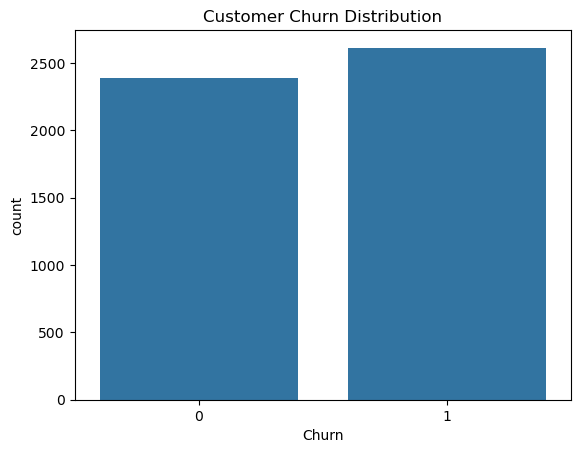

In [10]:
sns.countplot(x=df['Churn'])
plt.title("Customer Churn Distribution")
plt.show()

In [11]:
le = LabelEncoder()

df['ContractType'] = le.fit_transform(
    df['ContractType']
)

df['InternetService'] = le.fit_transform(
    df['InternetService']
)

In [12]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape)
print(X_test.shape)

(4000, 6)
(1000, 6)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [16]:
lr = LogisticRegression(max_iter=1000)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

In [17]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [19]:
def evaluate(y_true, pred, prob):
    print(
        "Accuracy:",
        round(
            accuracy_score(
                y_true,
                pred
            ),4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                pred
            ),4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                pred
            ),4
        )
    )

    print(
        "F1 Score:",
        round(
            f1_score(
                y_true,
                pred
            ),4
        )
    )

    print(
        "ROC-AUC:",
        round(
            roc_auc_score(
                y_true,
                prob
            ),4
        )
    )

In [20]:
print("LOGISTIC REGRESSION")

evaluate(
    y_test,
    lr_pred,
    lr_prob
)

LOGISTIC REGRESSION
Accuracy: 0.996
Precision: 0.9962
Recall: 0.9962
F1 Score: 0.9962
ROC-AUC: 1.0


In [21]:
print("RANDOM FOREST")

evaluate(
    y_test,
    rf_pred,
    rf_prob
)

RANDOM FOREST
Accuracy: 0.969
Precision: 0.9713
Recall: 0.9694
F1 Score: 0.9703
ROC-AUC: 0.9969


In [22]:
scores_lr = cross_val_score(
    lr,
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring='accuracy'
)

print(scores_lr)
print(scores_lr.mean())

[0.995 0.998 1.    0.995 0.997]
0.9970000000000001


In [23]:
scores_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores_rf)
print(scores_rf.mean())

[0.97  0.97  0.97  0.976 0.967]
0.9705999999999999


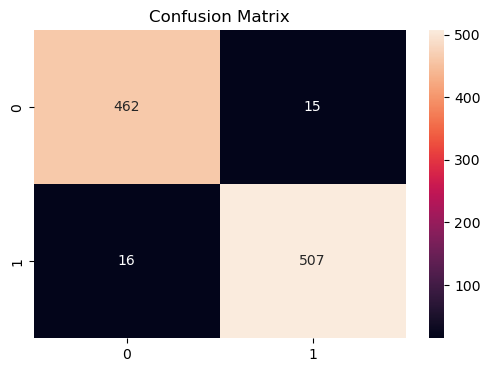

In [24]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

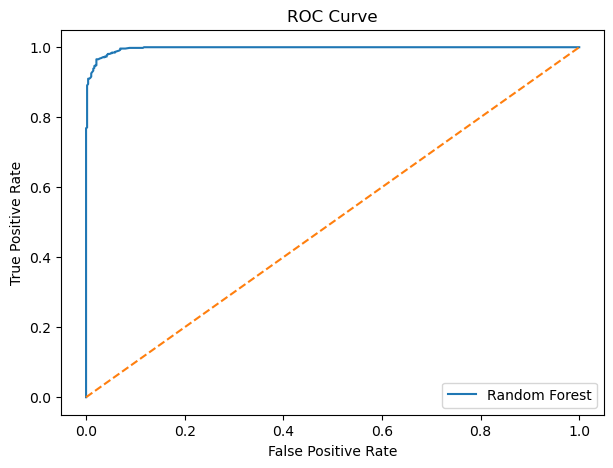

In [25]:
fpr, tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label='Random Forest'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

           Feature  Importance
2   MonthlyCharges    0.369299
1           Tenure    0.293569
5     SupportCalls    0.260001
0              Age    0.050652
4  InternetService    0.013369
3     ContractType    0.013111


In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.996   0.996176  0.996176  0.996176
1        Random Forest     0.969   0.971264  0.969407  0.970335
